<a href="https://colab.research.google.com/github/harishmuh/Python-for-Data-Science-Analysis/blob/main/Statistics_and_data_visualization_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Statistics descriptive and inferential exercise**
---

In this exercise, we will work with the Melbourne Housing dataset. The dataset offers a detailed snapshot of Melbourne’s real estate market, which has seen substantial growth in recent years. Originally curated by Tony Pino, this dataset was scraped from Domain.com.au and cleaned for analysis. It includes a variety of features such as property address, type, number of rooms, selling method, agent, price, and proximity to the city center.

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# additional settings
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

In [2]:
# loading dataset
url = 'https://raw.githubusercontent.com/harishmuh/Python-for-Data-Science-Analysis/refs/heads/main/datasets/melb_data.csv'
df = pd.read_csv(url)
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


**Column description**

The description of the features or columns can be seen as below

| Column     | Description                                                                                          |
|----------------|------------------------------------------------------------------------------------------------------|
| Address         | Street address of the property                                                                      |
| Suburb          | Name of the suburb where the property is located                                                    |
| Rooms           | Total number of rooms (including bedrooms and living areas)                                         |
| Bedroom2        | Number of bedrooms (scraped from a different source)                                                |
| Bathroom        | Number of bathrooms                                                                                 |
| Car             | Number of car spots                                                                                 |
| Landsize        | Land size in square meters                                                                          |
| BuildingArea    | Building area in square meters                                                                      |
| Price           | Sale price of the property in AUD                                                                   |
| Type            | Property type: `h` (house), `u` (unit), `t` (townhouse), `dev site` (development site), etc.       |
| Method          | Selling method: `S`, `SP`, `PI`, `W`, etc. (explained below)                                        |
| SellerG         | Real estate agent/company                                                                           |
| Date            | Date the property was sold                                                                          |
| Distance        | Distance from Central Business District (CBD) in kilometers                                        |
| Regionname      | Region classification such as Western Metropolitan, Northern Victoria, etc.                        |
| Propertycount   | Total number of properties in the suburb                                                            |
| CouncilArea     | Name of the governing council for the area                                                          |






**Method codes:**

S: Sold

SP: Sold prior

PI: Passed in

PN: Sold prior, not disclosed

SN: Sold, not disclosed

NB: No bid

VB: Vendor bid

W: Withdrawn prior to auction

SA: Sold after auction

SS: Sold after auction, price not disclosed

N/A: Price or highest bid not available

**Type codes:**

h: House, cottage, villa, semi, terrace

u: Unit, duplex

t: Townhouse

dev site: Development site

o res: Other residential

**No 1. Display descriptive statistics on the variables Rooms, Distance, Landsize, and Price!**

In [3]:
# Descriptive statistics
df[['Rooms', 'Distance', 'Landsize', 'Price']].describe()

,Rooms,Distance,Landsize,Price
count,13580.000000,13580.000000,13580.000000,1.358000e+04
mean,2.937997,10.137776,558.416127,1.075684e+06
std,0.955748,5.868725,3990.669241,6.393107e+05
min,1.000000,0.000000,0.000000,8.500000e+04
25%,2.000000,6.100000,177.000000,6.500000e+05
50%,3.000000,9.200000,440.000000,9.030000e+05
75%,3.000000,13.000000,651.000000,1.330000e+06
max,10.000000,48.100000,433014.000000,9.000000e+06


**No. 2.**
* How many rooms are in the most expensive house?
* What is the average price of a house located closest to the CBD (Distance)?
* What is the average price of a house with a land area (Landsize) that is one standard deviation above the average land area?
* What is the range of house prices (Price) in the Southern Metropolitan region?

In [4]:
# Observing row with the highest room price
df[df['Price'] == df['Price'].max()]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
12094,Mulgrave,35 Bevis St,3,h,9000000.0,PI,Hall,29/07/2017,18.8,3170.0,3.0,1.0,1.0,744.0,117.0,1960.0,Monash,-37.93168,145.16126,South-Eastern Metropolitan,7113.0


In [5]:
# Room with the highest price
df[df['Price'] == df['Price'].max()]['Rooms']

,Rooms
12094,3


In [6]:
# Filtering rows with the minimum distance
df[df['Distance'] == df['Distance'].min()]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
9620,Melbourne,19/300 King St,2,u,740000.0,VB,MICM,17/06/2017,0.0,3000.0,2.0,1.0,1.0,0.0,113.0,1999.0,Melbourne,-37.81317,144.95452,Northern Metropolitan,17496.0
10393,Melbourne,1814/250 Elizabeth St,2,u,720000.0,S,Harcourts,27/05/2017,0.0,3000.0,2.0,1.0,1.0,0.0,86.0,1976.0,Melbourne,-37.81267,144.96273,Northern Metropolitan,17496.0
10739,Melbourne,61/299 Queen St,2,u,1075000.0,SP,Melbourne,8/07/2017,0.0,3000.0,2.0,2.0,1.0,0.0,NaN,NaN,Melbourne,-37.81141,144.95879,Northern Metropolitan,17496.0
11428,Melbourne,806/22 Coromandel Pl,2,u,387000.0,S,Galldon,15/07/2017,0.0,3000.0,2.0,1.0,0.0,0.0,47.0,2011.0,Melbourne,-37.81301,144.96924,Northern Metropolitan,17496.0
12073,Melbourne,709/87 Franklin St,2,u,565000.0,S,MICM,29/07/2017,0.0,3000.0,2.0,1.0,0.0,89.0,85.0,2003.0,Melbourne,-37.80802,144.96168,Northern Metropolitan,17496.0
12074,Melbourne,713/118 Russell St,2,u,540000.0,PI,Harcourts,29/07/2017,0.0,3000.0,2.0,1.0,0.0,0.0,NaN,1950.0,Melbourne,-37.81351,144.96908,Northern Metropolitan,17496.0


In [7]:
# What is the average price of a house located at the nearest CBD (Distance variable)?
print(df[df['Distance'] == df['Distance'].min()]['Price'].mean())

671166.6666666666


In [8]:
# What is the average price of a house whose land area (the variable Landsize) is 1 standard deviation above the mean land area?
print(df[df['Landsize'] > df['Landsize'].mean() + df['Landsize'].std()]['Price'].mean())

880776.6666666666


In [9]:
# What is the range of house prices (variable Price) in the Southern Metropolitan region?
df[df['Regionname'] == 'Southern Metropolitan']['Price'].max() - df[df['Regionname'] == 'Southern Metropolitan']['Price'].min()

7869000.0

**Question 3. An outlier value is a value that falls below Q1 - (1.5 * IQR) or above Q3 + (1.5 * IQR).**
* First, calculate Q1, Q2, and IQR in the Price column (house price).
* Count how many outlier values there are in the Price column!

In [10]:
# First calculate Q1, Q2, Q3 and IQR in the Price column (house price)
Q1 = df['Price'].quantile(0.25)
Q2 = df['Price'].quantile(0.5)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

print('Q1 =', Q1)
print('Q2 =', Q2)
print('Q3 =', Q3)
print('IQR =', IQR)

Q1 = 650000.0
Q2 = 903000.0
Q3 = 1330000.0
IQR = 680000.0


In [11]:
# Count how many outlier values there are in the Price column!
print(len(df[(df['Price'] < Q1 - (1.5 * IQR)) | (df['Price'] > Q3 + (1.5 * IQR))]))

612


In [12]:
# Count how many outlier values there are in the Price column!

# Break down the outliers location into lower and upper outlier

# Lower outliers
lower_outlier = len(df[df['Price'] < Q1 - (1.5 * IQR)])
print('Lower outlier:', lower_outlier)

# Upper outliers
upper_outlier = len(df[df['Price'] > Q3 + (1.5 * IQR)])
print('Upper outlier:', upper_outlier)

# Total outliers
total_outliers = lower_outlier + upper_outlier
print('Total outliers:', total_outliers)

Lower outlier: 0
Upper outlier: 612
Total outliers: 612


**Question 4. Test the normality assumption for the house price variable using:**
* Shapiro-Wilk Test
* D'Agostino and Pearson's Test

In [13]:
# Shapiro-Wilk Test of House Prices

from scipy.stats import shapiro

stat, pvalue = shapiro(df['Price'])
alpha = 0.05

if pvalue > alpha:
  print(f'pvalue = {pvalue}. pvalue > {alpha}. Fail to reject H0. We can assume that the data is normally distributed')
else:
  print(f'pvalue = {pvalue}. pvalue < {alpha}. Reject H0. We can assume that the data is NOT normally distributed')

pvalue = 1.4465718615128594e-79. pvalue < 0.05. Reject H0. We can assume that the data is NOT normally distributed


In [14]:
# D'Agostino and Pearson's Test
from scipy.stats import normaltest

stat, pvalue = normaltest(df['Price'])
alpha = 0.05

if pvalue > alpha:
  print(f'pvalue = {pvalue}. pvalue > {alpha}. Fail to reject H0. We can assume that the data is normally distributed')
else:
  print(f'pvalue = {pvalue}. pvalue < {alpha}. Reject H0. We can assume that the data is NOT normally distributed')

pvalue = 0.0. pvalue < 0.05. Reject H0. We can assume that the data is NOT normally distributed


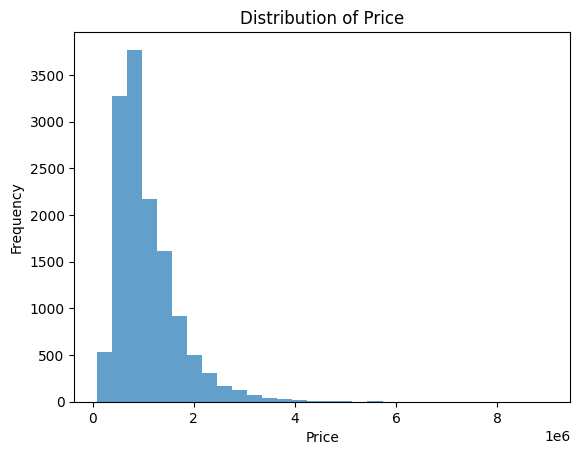

In [15]:
# Visualize the distribution of house 'Price'
plt.hist(df['Price'], bins=30, alpha=0.7)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

**Question 5. If it is assumed that the parametric statistical requirements have been met, calculate how strong the correlation between the Rooms variable and Price is, as well as the direction of the correlation!**

In [16]:
# Calculate the correlation between the Rooms and Price variables, as well as the direction of the correlation!
print(df['Rooms'].corr(df['Price'], method='pearson'))

0.4966336761865308


**Question 6.**

* Of the several Regionnames, which Regionname has the variable number of rooms (Rooms) that has the strongest correlation with the variable house price (Price)?
* Assuming it meets the requirements for parametric statistics.

In [17]:
# Of the several Regionnames, which Regionname has the variable number of rooms (Rooms) that has the strongest correlation with the variable house price (Price)?
df.groupby('Regionname')['Rooms'].corr(df['Price'], method='pearson')

,Rooms
Regionname,
Eastern Metropolitan,0.502993
Eastern Victoria,0.314423
Northern Metropolitan,0.392813
Northern Victoria,0.361144
South-Eastern Metropolitan,0.267799
Southern Metropolitan,0.683744
Western Metropolitan,0.476030
Western Victoria,0.551887


**Question 7. Assuming that the parametric statistics do not meet the criteria, calculate the correlation between the Distance and Price variables, and the direction of the correlation.**

In [18]:
# If it is assumed that the parametric statistics do not meet the requirements, calculate the correlation strength between the Distance variable and Price, as well as the direction of the correlation.
print(df['Distance'].corr(df['Price'], method='spearman'))

-0.12998984131880323


**Question 8**

* Based on the several Regionnames, which Regionname is least correlated with the house price variable (Price)?
* Also display the Regionname that most correlates between these two variables!
Assuming that the parametric statistics requirements are met.

In [19]:
# Of the several Regionnames, which Regionname is the one whose distance to the CBD (Distance) is least correlated with the house price (Price)?
df_region = df.groupby('Regionname')['Distance'].corr(df['Price'], method='pearson')
df_region.sort_values(ascending=False)

,Distance
Regionname,
Northern Victoria,0.089566
Southern Metropolitan,0.002489
Western Victoria,-0.046064
Eastern Metropolitan,-0.124356
South-Eastern Metropolitan,-0.285564
Western Metropolitan,-0.334086
Eastern Victoria,-0.345699
Northern Metropolitan,-0.368552


**Number 9. Test the hypothesis whether the purchasing method is related to the type of house (dependent) or not (independent)!**

Hypothesis:
* Ho: The two variables are independent
* Ha: The two variables are dependent.

In [20]:
# Test the hypothesis whether the purchasing method/Method is related to the type of house/Type (dependent) or not related to each other (independent)! from scipy.stats import chi2_contingency
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['Method'], df['Type'])
chi2, pvalue, dof, expected = chi2_contingency(contingency_table)
alpha = 0.05

if pvalue > alpha:
  print(f'''
pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail To Reject Ho.
We do NOT have enough evidence to say that Method and Type are dependent.
''')
else:
  print(f'''
pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
We have enough evidence to say that Method and Type are dependent.
''')


pvalue = 0.00000. pvalue <= 0.05. Reject Ho.
We have enough evidence to say that Method and Type are dependent.



In [21]:
contingency_table

Type,h,t,u
Method,,,
PI,1069,134,361
S,6507,723,1792
SA,66,7,19
SP,1079,143,481
VB,728,107,364


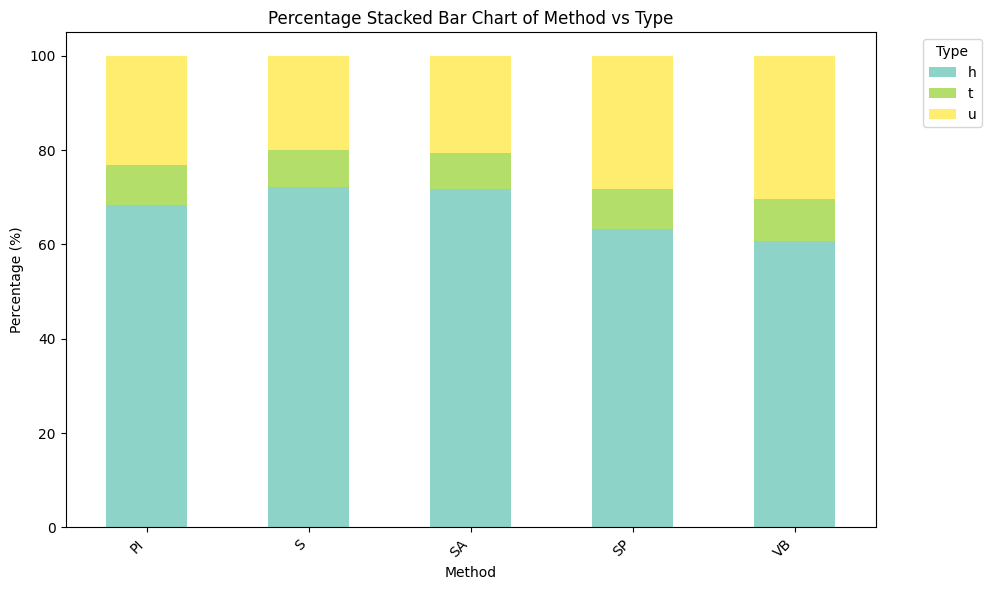

In [22]:
# Stacked bar - association test (in percentage)
# Contingency table: frequency counts
contingency_table = pd.crosstab(df['Method'], df['Type'])

# Convert to percentages row-wise
percentage_table = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

# Plot the percentage stacked bar chart
percentage_table.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set3')

# Add labels and title
plt.title('Percentage Stacked Bar Chart of Method vs Type')
plt.xlabel('Method')
plt.ylabel('Percentage (%)')
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


**Number 10.**

Test the hypothesis whether the average house prices (Price) between Regionnames are different or the same! Assuming the requirements for parametric statistics are met.

Hypothesis:
* Ho: μ1 = μ2 = … = μk (The average house prices between Regionnames are the same)
* Ha: There is at least one pair of Regionnames where the average house prices are different, but we don't know which one.

In [23]:
# Parse Regionname
df['Regionname'].value_counts().sort_index()

,count
Regionname,
Eastern Metropolitan,1471
Eastern Victoria,53
Northern Metropolitan,3890
Northern Victoria,41
South-Eastern Metropolitan,450
Southern Metropolitan,4695
Western Metropolitan,2948
Western Victoria,32


In [24]:
# Hypothesis test whether the average house price (Price) between Regionnames is different or the same! It is assumed that the requirements of parametric statistics are met
from scipy.stats import f_oneway

stat, pvalue = f_oneway(df[df['Regionname']== 'Eastern Metropolitan']['Price'],
df[df['Regionname']== 'Eastern Victoria']['Price'],
df[df['Regionname']== 'Northern Metropolitan']['Price'],
df[df['Regionname']== 'Northern Victoria']['Price'],
df[df['Regionname']== 'South-Eastern Metropolitan']['Price'],
df[df['Regionname']== 'Southern Metropolitan']['Price'],
df[df['Regionname']== 'Western Metropolitan']['Price'],
df[df['Regionname']== 'Western Victoria']['Price']
)

if pvalue > alpha:
  print(f'''
pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail To Reject Ho.
We DO NOT have enough evidence to say that there is at least one group whose average house prices between region names differ, but we don't know which one.
''')
else:
  print(f'''
pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
We have enough evidence to say that there is at least one group whose average house prices between region names differ, but we don't know which one.
''')


pvalue = 0.00000. pvalue <= 0.05. Reject Ho.
We have enough evidence to say that there is at least one group whose average house prices between region names differ, but we don't know which one.



In [25]:
# Median price per region
# Group by 'Regionname' dan hitung median dari 'Price'
median_prices = df.groupby('Regionname')['Price'].median().sort_values(ascending=False)
median_prices

,Price
Regionname,
Southern Metropolitan,1250000.0
Eastern Metropolitan,1010000.0
South-Eastern Metropolitan,850000.0
Northern Metropolitan,806250.0
Western Metropolitan,793000.0
Eastern Victoria,670000.0
Northern Victoria,540000.0
Western Victoria,400000.0


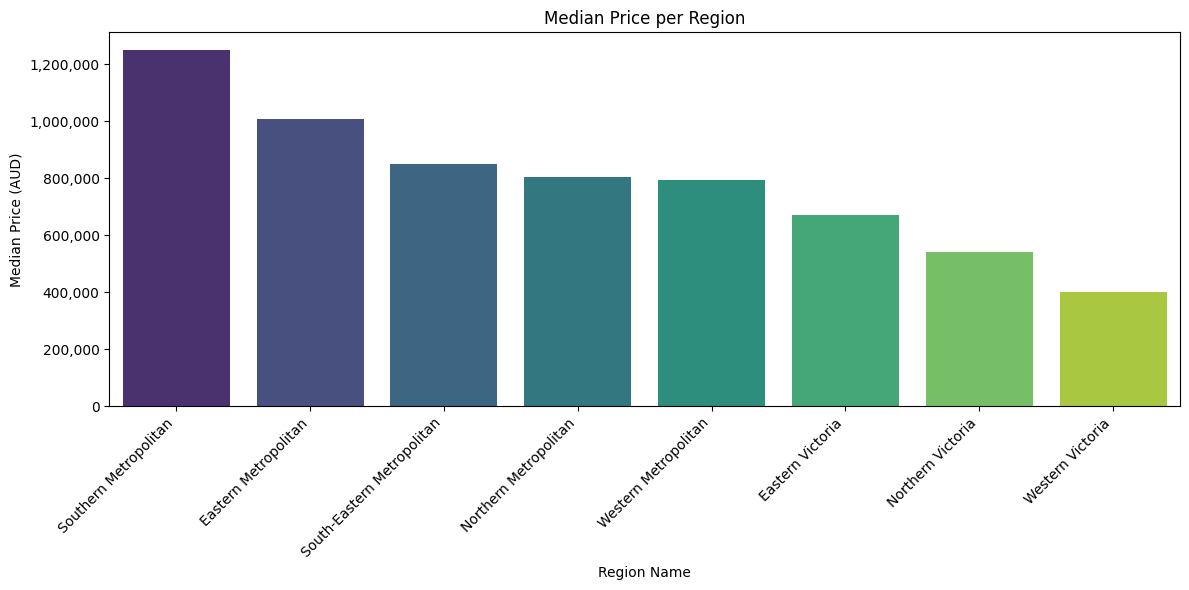

In [26]:
# Visual comparison of median price
# Add library
from matplotlib.ticker import StrMethodFormatter

# Reset the index so that 'Regionname' becomes a regular column
median_prices_df = median_prices.reset_index()

# Create a barplot
plt.figure(figsize=(12, 6))
sns.barplot(data=median_prices_df, x='Regionname', y='Price', palette='viridis')

# Add labels and rotation
plt.title('Median Price per Region')
plt.xlabel('Region Name')
plt.ylabel('Median Price (AUD)')
#plt.ylabel('Median Price (Millions)')
plt.xticks(rotation=45, ha='right')

# Format Y-axis with comma separators
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Format Y-axis in Millions (e.g., 1.5M)
#formatter = FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
#plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

In [27]:
# Multiple comparison to compare variable means

# Import library
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform one-way ANOVA
anova_result = f_oneway(*(df[df['Regionname'] == region]['Price'] for region in df['Regionname'].unique()))

# Perform Tukey's HSD test for multiple comparisons
tukey_results = pairwise_tukeyhsd(df['Price'], df['Regionname'])

# Print the summary of the results
print(tukey_results.summary())

                            Multiple Comparison of Means - Tukey HSD, FWER=0.05                            
          group1                     group2             meandiff   p-adj      lower        upper     reject
-----------------------------------------------------------------------------------------------------------
      Eastern Metropolitan           Eastern Victoria -404098.8418    0.0  -657195.7519 -151001.9317   True
      Eastern Metropolitan      Northern Metropolitan  -205908.552    0.0  -261317.5629 -150499.5411   True
      Eastern Metropolitan          Northern Victoria  -509250.366    0.0  -795876.8139  -222623.918   True
      Eastern Metropolitan South-Eastern Metropolitan -181135.8498    0.0  -278654.9578  -83616.7419   True
      Eastern Metropolitan      Southern Metropolitan  268883.7351    0.0   214793.8254  322973.6448   True
      Eastern Metropolitan       Western Metropolitan -237659.1142    0.0  -295446.1684 -179872.0601   True
      Eastern Metropolitan  

### **Number 11**

Display a visualization that shows the overall distribution of house prices!

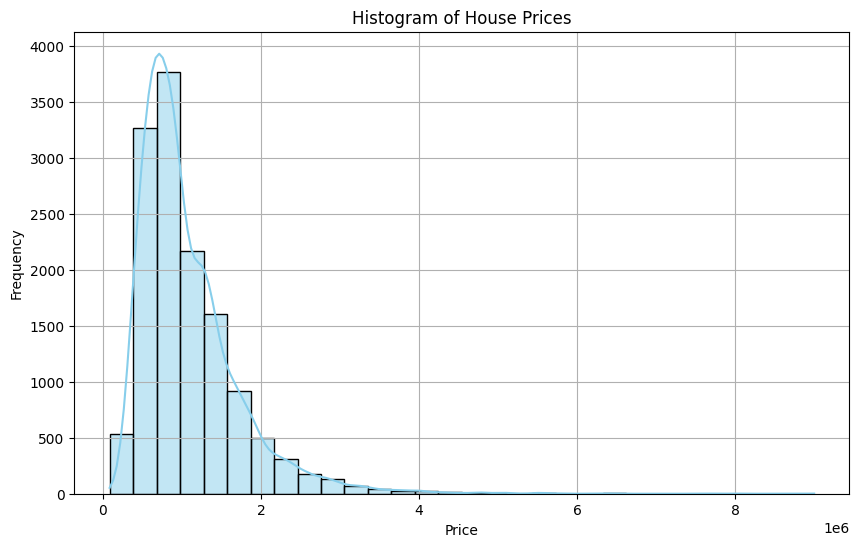

In [28]:
# House price distribution
# Plotting histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=30, color='skyblue', edgecolor='black', kde=True)
plt.title('Histogram of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### **Number 12**

Show a visualization depicting **average home prices** by **Region Name**!

<Figure size 1500x800 with 0 Axes>

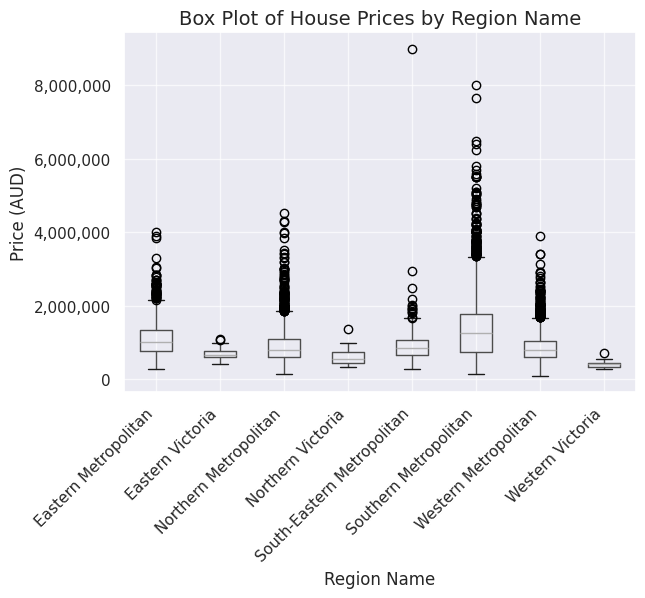

In [54]:
# Boxplot: House price vs Region name

# Add a library
from matplotlib.ticker import StrMethodFormatter

# Set up the figure
plt.figure(figsize=(15, 8))

# Boxplot using pandas (by default, sets a suptitle)
box_plot = df.boxplot(column='Price', by='Regionname', grid=True)

# Improve the plot
plt.title('Box Plot of House Prices by Region Name', fontsize=14)
plt.suptitle('')  # Remove default 'Boxplot grouped by Regionname'
plt.xlabel('Region Name', fontsize=12)
plt.ylabel('Price (AUD)', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Format y-axis to show comma separators for currency
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Add grid for readability
plt.grid(True, alpha=0.7)

# Adjust layout to prevent label clipping
# plt.tight_layout()

# Show plot
plt.show()


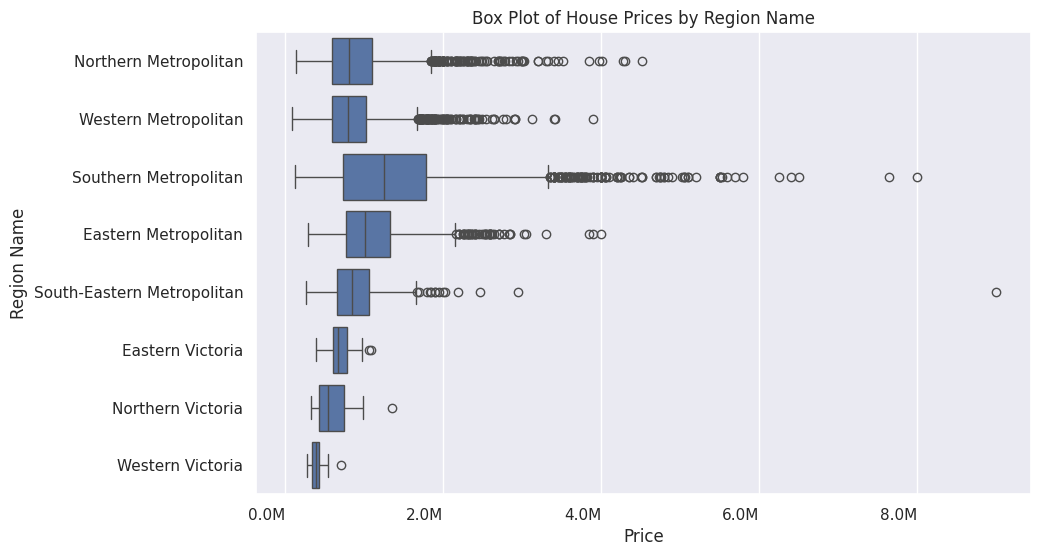

In [30]:
# Boxplot: House price vs Region name

# Setting style and figure
sns.set(style="darkgrid")
plt.figure(figsize=(10, 6))

# Plotting a box plot # Seaborn
box_plot = sns.boxplot(x='Price', y='Regionname', data=df)

# Add library
from matplotlib.ticker import FuncFormatter

plt.title('Box Plot of House Prices by Region Name')
plt.xlabel('Price')
plt.ylabel('Region Name')
#Format x-axis in Millions (e.g., 1.5M)
formatter = FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
plt.gca().xaxis.set_major_formatter(formatter)
plt.xticks(ha='right')
plt.show()

### **Number 13**

Show a visualization depicting the **number of houses** for **each type** of house (Type)!

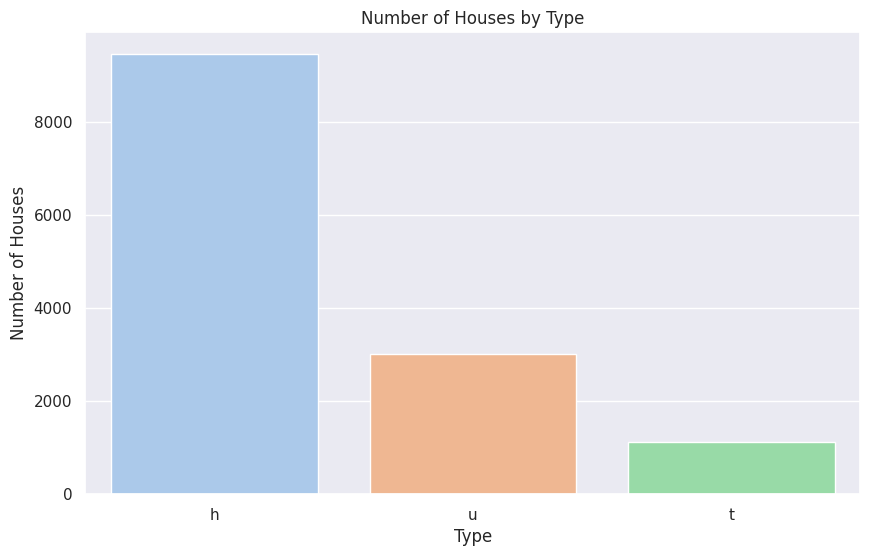

In [31]:
# House type by number

# Setting style
sns.set(style="darkgrid")

# Plot bar plot
plt.figure(figsize=(10, 6))
sns.countplot(x='Type', data=df, palette='pastel')
plt.title('Number of Houses by Type')
plt.xlabel('Type')
plt.ylabel('Number of Houses')
plt.show()

### **Number 14**

Show a visualization showing the **correlation value** between the variables 'Rooms', 'Price', 'Distance',
'BuildingArea', 'YearBuilt'! Which variable has the strongest correlation with house price?

In [32]:
# Correlation
df_corr = df[['Rooms', 'Price', 'Distance', 'BuildingArea', 'YearBuilt']].corr(method='spearman')
df_corr

,Rooms,Price,Distance,BuildingArea,YearBuilt
Rooms,1.000000,0.539886,0.351416,0.775193,-0.072058
Price,0.539886,1.000000,-0.129990,0.631425,-0.368080
Distance,0.351416,-0.129990,1.000000,0.287116,0.228634
BuildingArea,0.775193,0.631425,0.287116,1.000000,0.003002
YearBuilt,-0.072058,-0.368080,0.228634,0.003002,1.000000


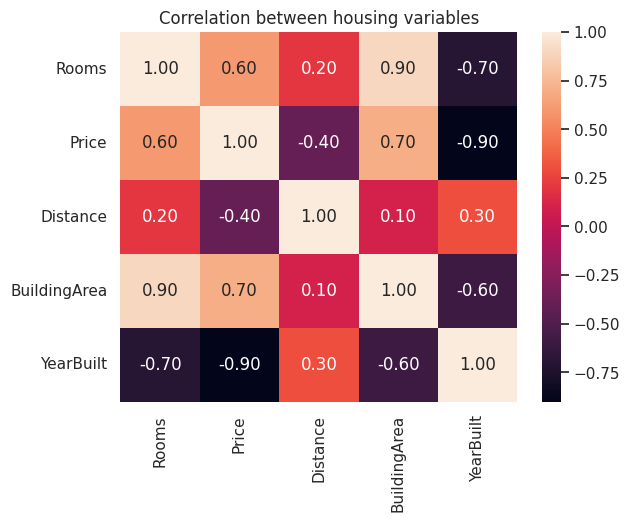

In [33]:
# Visualization # Heatmap
sns.heatmap(df_corr.corr(method='spearman'), annot=True, fmt='.2f')
plt.title('Correlation between housing variables')
plt.show()

**Rooms vs. Price:** The correlation between the number of rooms (Rooms) and house price (Price) is 0.539886. This indicates a fairly strong positive relationship between the number of rooms and house prices. This means that the more rooms a house has, the more likely its price will rise.

**Distance vs. Price:** The correlation between distance to the city center (Distance) and house price (Price) is -0.129990. A negative value indicates a weak negative relationship between distance to the city center and house prices. In other words, the further a house is from the city center, the lower the house price tends to be, although the correlation is weak.

**Building Area vs. Price:** The correlation between building area (Building Area) and house price (Price) is 0.631425. This indicates a strong positive relationship between building area and house prices. This means that the larger the building area of a house, the more likely its price will rise.

**Year Built vs. Price:** The correlation between year built (YearBuilt) and house price (Price) is -0.368080. A negative value indicates a fairly strong negative relationship between year built and house price. This means that the older the house, the lower its price tends to be.

Therefore, from the correlation results, the variable 'BuildingArea' has the strongest correlation with house price, indicating that building area has the most significant influence on house prices.

### **Number 15**

Display a visualization depicting the correlation between the variables **BuildingArea** and **Price**! Before visualizing, first (temporarily) remove houses with a Building Area greater than 2,000 m2 (as they are considered outliers)!

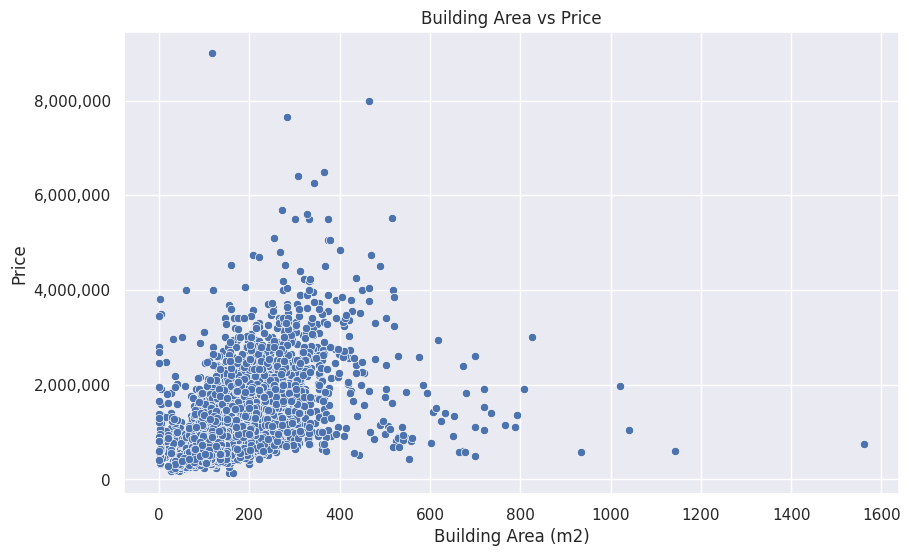

In [34]:
# Removing outliers for greater area than 2000 m2 (BuildingArea > 2000)
df1 = df[df['BuildingArea'] <= 2000]

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df1, x='BuildingArea', y='Price')

# Format Y-axis with comma separators
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Display
plt.title('Building Area vs Price')
plt.xlabel('Building Area (m2)')
plt.ylabel('Price')
plt.grid(True)
plt.show()

### **Number 16**

From the previous visualization, add the **Type** variable to the visualization so that the correlation between building area (**Building Area**) and house price (**Price**) can also be observed based on the type (Type)!

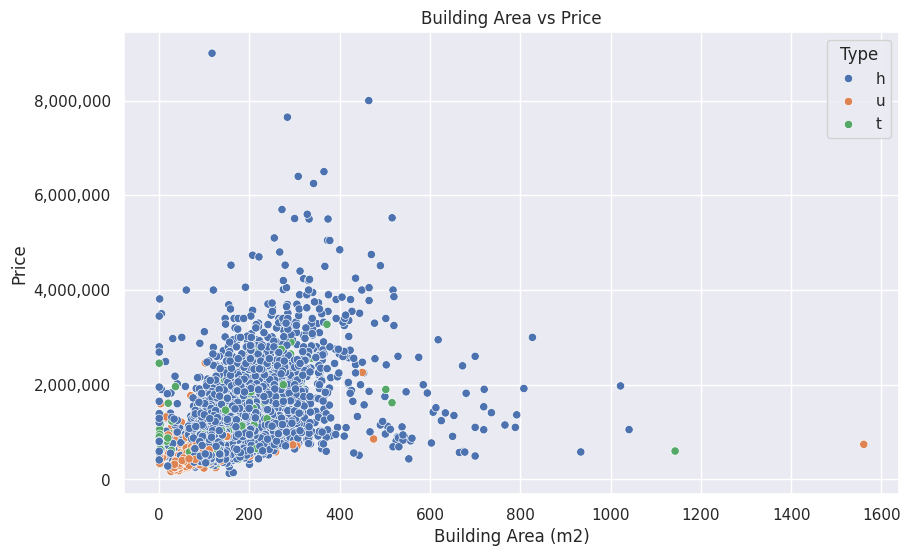

In [35]:
# Removing outliers for greater area than 2000 m2 (BuildingArea > 2000)
df1 = df[df['BuildingArea'] <= 2000]

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df1, x='BuildingArea', y='Price', hue= 'Type')

# Format Y-axis with comma separators
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Display
plt.title('Building Area vs Price')
plt.xlabel('Building Area (m2)')
plt.ylabel('Price')
plt.grid(True)
plt.show()

### **Number 17**

Show a visualization depicting the **change in the number of homes** sold from Jan 2016 to Dec 2017!

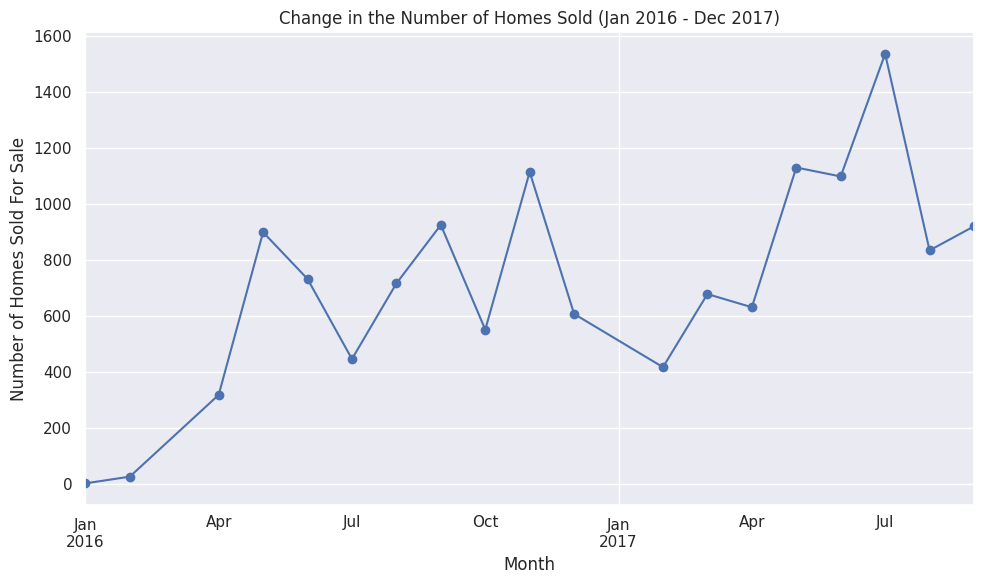

In [36]:
# Convert the 'Date' column to a datetime type
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Aggregate the data to calculate the number of homes sold each month
df['YearMonth'] = df['Date'].dt.to_period('M')
house_sold_per_month = df.groupby('YearMonth').size()

# Create a visualization
plt.figure(figsize=(10, 6))
house_sold_per_month.plot(kind='line', marker='o', color='b')
plt.title('Change in the Number of Homes Sold (Jan 2016 - Dec 2017)')
plt.xlabel('Month')
plt.ylabel('Number of Homes Sold For Sale')
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

### **Number 18**

Show a visualization depicting a comparison of house price distributions (Price) based on house type (Type)! At what price point for a "t" (townhouse) house could be considered an outlier?

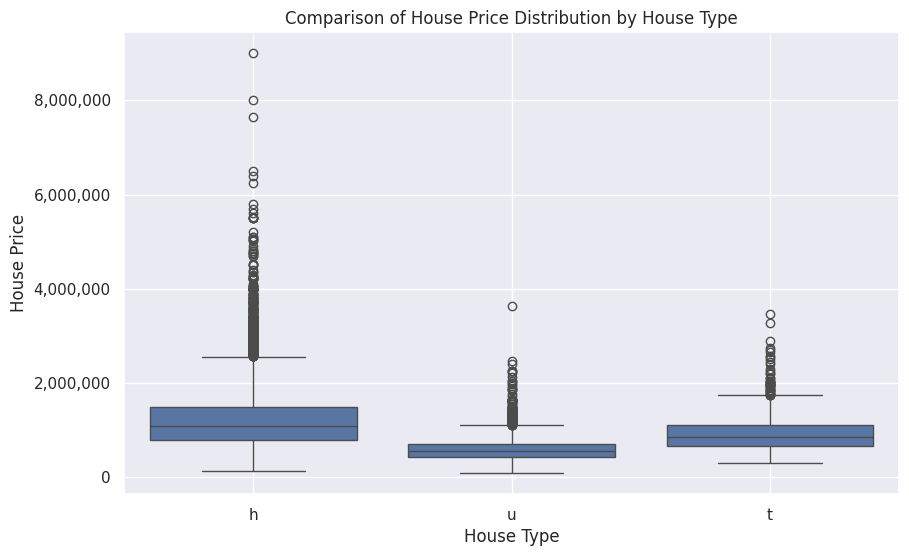

Lower bound for outliers of house price in type 't' (townhouse): 22150.0


In [37]:
# Boxplot visualization to compare the distribution of house prices by house type
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Type', y='Price')

# Format Y-axis with comma separators
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title('Comparison of House Price Distribution by House Type')
plt.xlabel('House Type')
plt.ylabel('House Price')
plt.grid(True)
plt.show()

# Determining outliers for houses of type "t" (townhouse)
townhouse_prices = df[df['Type'] == 't']['Price']
Q1 = townhouse_prices.quantile(0.25)
Q3 = townhouse_prices.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound for outliers of house price in type 't' (townhouse):", lower_bound)